In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [5]:
def assign_grades(marks, scale):
    """Assign grades based on defined scale."""
    if scale == 5:
        bins = [0, 50, 60, 70, 80, 100, np.inf]
        grades = ['F', 'D', 'C', 'B', 'A']
    elif scale == 7:
        bins = [0, 50, 55, 60, 65, 70, 80, 100, np.inf]
        grades = ['F', 'D', 'C-', 'C', 'C+', 'B', 'A']
    else:
        raise ValueError("Invalid grade scale")
    return np.array([grades[min(np.digitize(m, bins) - 1, len(grades) - 1)] for m in marks])


In [6]:
# Generate marks for 200 students in Probability & Statistics
np.random.seed(42)
marks = np.random.normal(loc=70, scale=15, size=200)
marks = np.clip(marks, 0, 100)  # Ensure marks are within 0-100

grades_5 = assign_grades(marks, scale=5)
grades_7 = assign_grades(marks, scale=7)


In [7]:
# Display marks and grades
print("Marks and Grades (5-scale):")
for i in range(len(marks)):
    print(f"Student {i+1}: Marks = {marks[i]:.2f}, Grade = {grades_5[i]}")


Marks and Grades (5-scale):
Student 1: Marks = 77.45, Grade = B
Student 2: Marks = 67.93, Grade = C
Student 3: Marks = 79.72, Grade = B
Student 4: Marks = 92.85, Grade = A
Student 5: Marks = 66.49, Grade = C
Student 6: Marks = 66.49, Grade = C
Student 7: Marks = 93.69, Grade = A
Student 8: Marks = 81.51, Grade = A
Student 9: Marks = 62.96, Grade = C
Student 10: Marks = 78.14, Grade = B
Student 11: Marks = 63.05, Grade = C
Student 12: Marks = 63.01, Grade = C
Student 13: Marks = 73.63, Grade = B
Student 14: Marks = 41.30, Grade = F
Student 15: Marks = 44.13, Grade = F
Student 16: Marks = 61.57, Grade = C
Student 17: Marks = 54.81, Grade = D
Student 18: Marks = 74.71, Grade = B
Student 19: Marks = 56.38, Grade = D
Student 20: Marks = 48.82, Grade = F
Student 21: Marks = 91.98, Grade = A
Student 22: Marks = 66.61, Grade = C
Student 23: Marks = 71.01, Grade = B
Student 24: Marks = 48.63, Grade = F
Student 25: Marks = 61.83, Grade = C
Student 26: Marks = 71.66, Grade = B
Student 27: Marks =

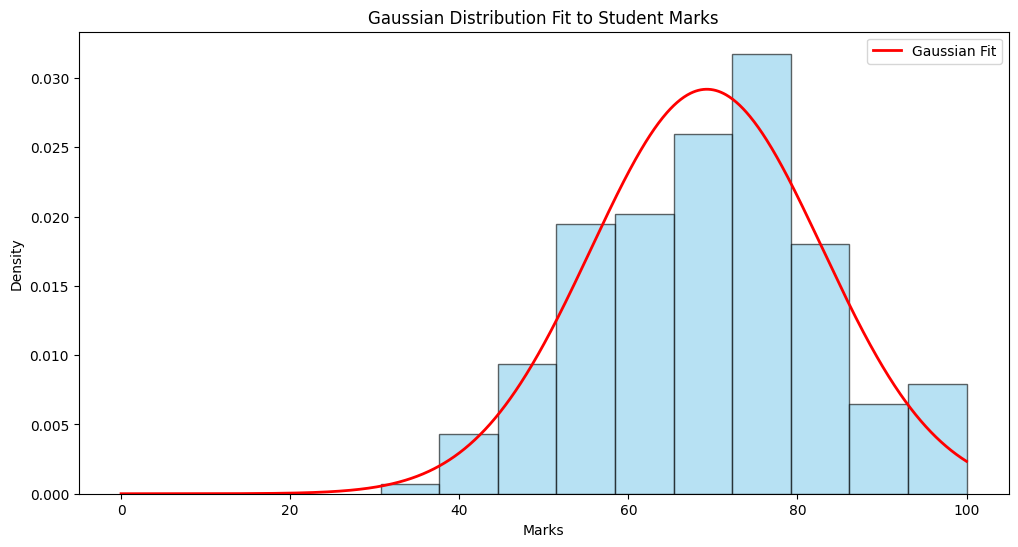

In [8]:
# Fit Gaussian distribution
x = np.linspace(0, 100, 1000)
pdf = stats.norm.pdf(x, np.mean(marks), np.std(marks))

# Plot distribution
plt.figure(figsize=(12, 6))
plt.hist(marks, bins=10, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.plot(x, pdf, color='red', linewidth=2, label='Gaussian Fit')
plt.xlabel("Marks")
plt.ylabel("Density")
plt.title("Gaussian Distribution Fit to Student Marks")
plt.legend()
plt.show()

In [9]:
# Save results
df_results = np.column_stack((marks, grades_5, grades_7))
np.savetxt("6_student_grades.csv", df_results, delimiter=",", fmt="%s", header="Marks,Grade_5_Scale,Grade_7_Scale", comments='')
print("Grades saved to student_grades.csv")


Grades saved to student_grades.csv
